# **ETTh1 Dataset Analysis**
- Using Google Colab for execution

In [ ]:
# ONLY DO THIS ONCE WHEN INITIALIZING THE FILE

# Cloning the GitHub Repo into Google Colab -- REQUIRES THE REPO TO BE PUBLIC
# !git clone https://github.com/jauric/TUB-SS-26_Deep-Learning-Time-Series.git

# Navigating Colab into the cloned repo
# %cd TUB-SS-26_Deep-Learning-Time-Series

In [3]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [4]:
ETTh1_link = "~/PythonWorkspace/timeseries/data/ETTh1.csv"

data_ETTh1 = pd.read_csv(ETTh1_link)
data_ETTh1.head()

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


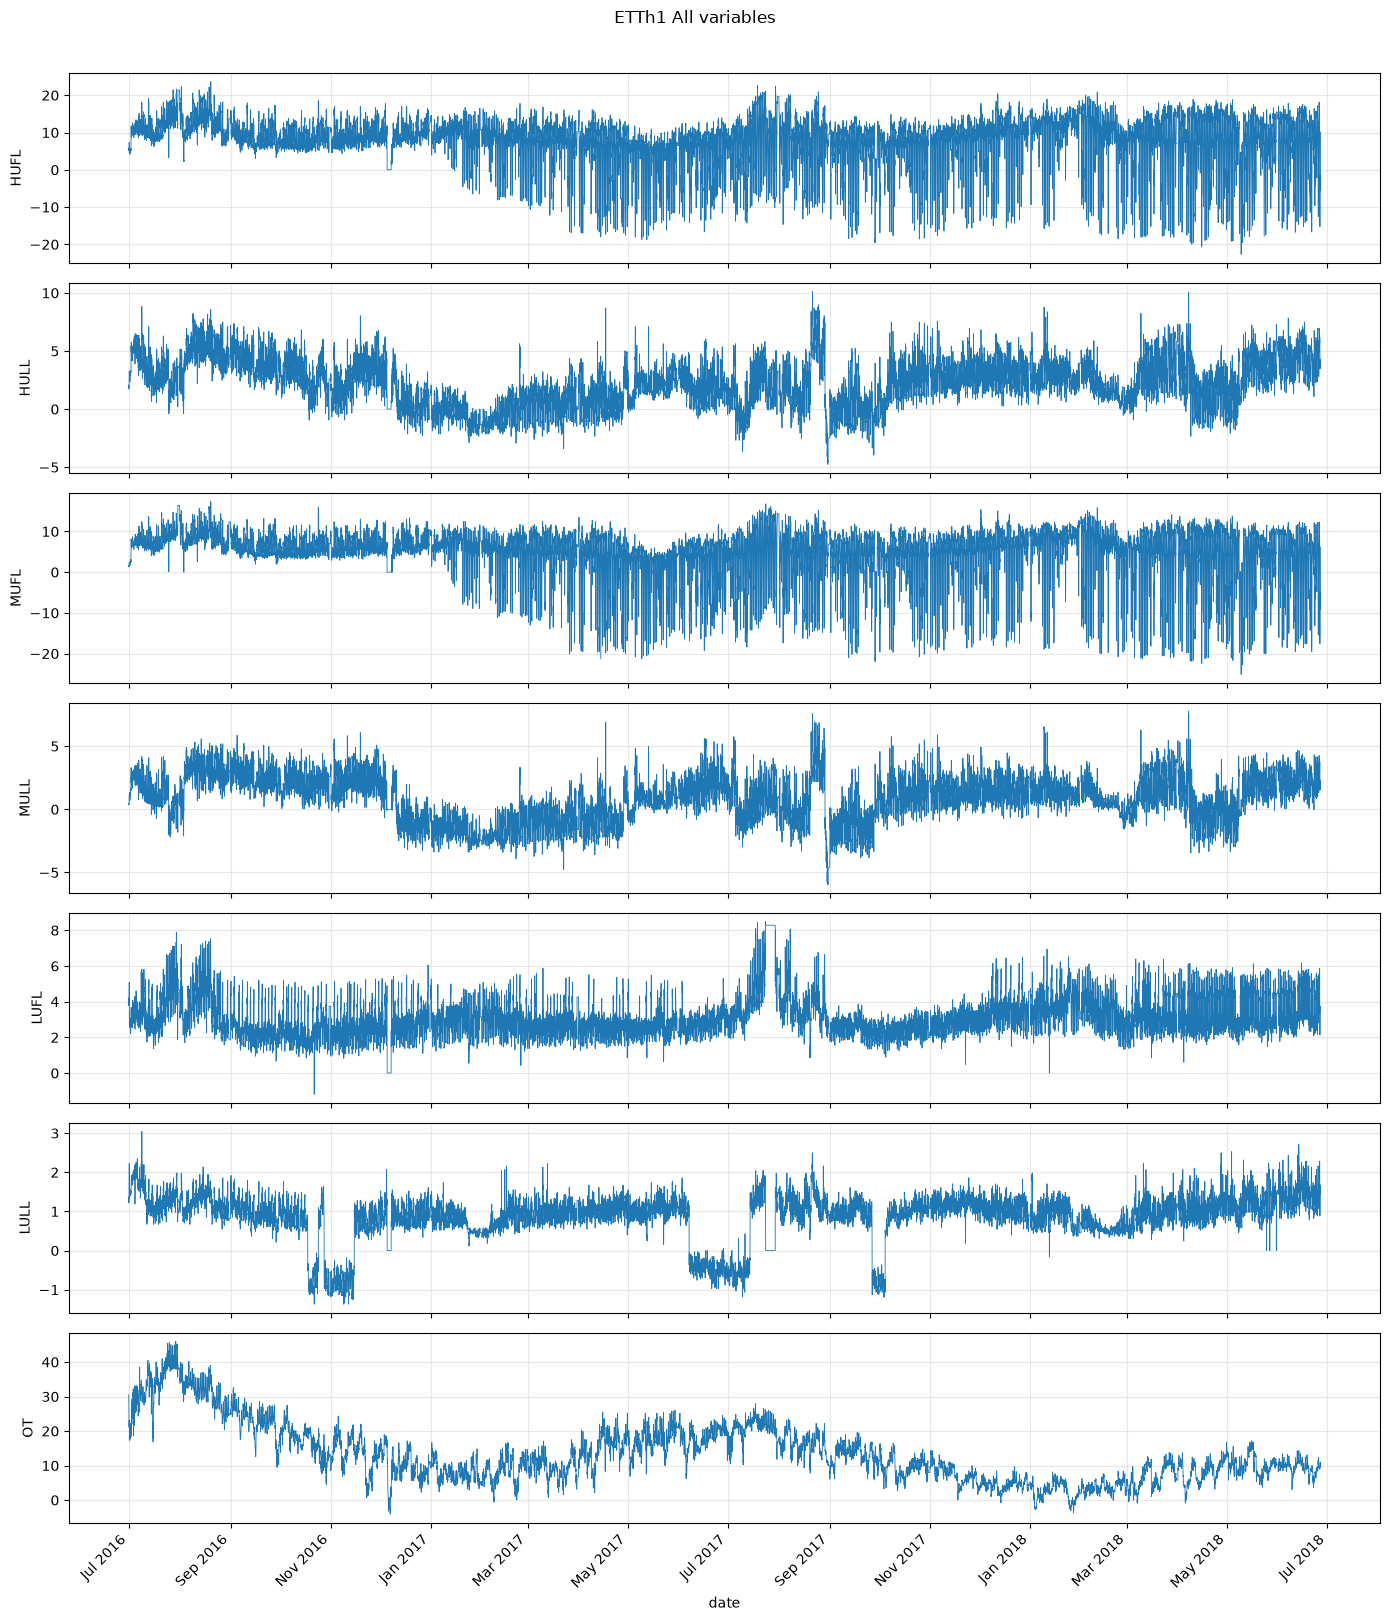

In [5]:
dates = pd.to_datetime(data_ETTh1["date"])

data_ETTh1 = data_ETTh1.set_index("date")

# Visualize all 7 features
fig, axes = plt.subplots(7, 1, figsize=(14, 16), sharex=True)
for ax, col in zip(axes, data_ETTh1.columns):
    ax.plot(dates, data_ETTh1[col], linewidth=0.6)
    ax.set_ylabel(col)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("date")
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha("right")

fig.suptitle("ETTh1 All variables", y=1.01)
plt.tight_layout()
plt.show()

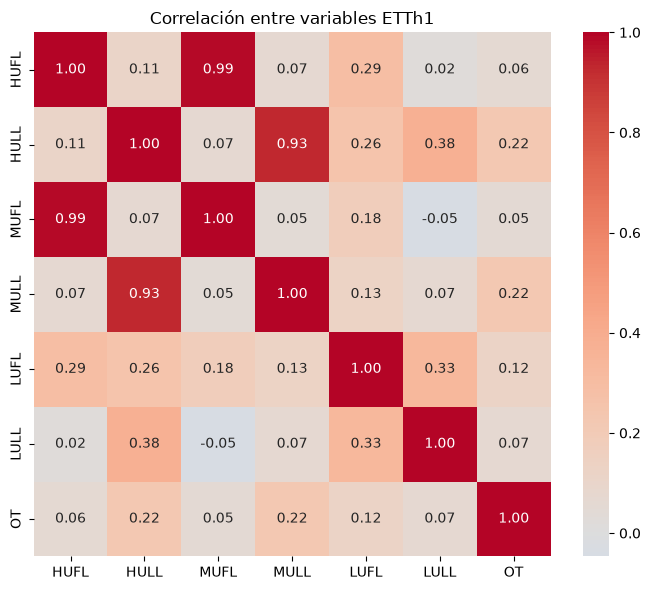

In [6]:
import seaborn as sns

corr = data_ETTh1.corr()
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlación entre variables ETTh1")
plt.tight_layout()
plt.show()

In [7]:
df = data_ETTh1
lags = range(0, 25)  # hasta 24h de retraso
for col in ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL"]:
    corrs = [df[col].shift(lag).corr(df["OT"]) for lag in lags]
    best_lag = np.argmax(np.abs(corrs))
    print(f"{col}: mejor correlación = {corrs[best_lag]:.3f} en lag={best_lag}h")

HUFL: mejor correlación = 0.147 en lag=15h
HULL: mejor correlación = 0.263 en lag=10h
MUFL: mejor correlación = 0.141 en lag=15h
MULL: mejor correlación = 0.254 en lag=10h
LUFL: mejor correlación = 0.133 en lag=7h
LULL: mejor correlación = 0.079 en lag=6h


In [8]:
for lag in [1, 6, 10, 15, 24]:
    print(f"OT autocorr en lag={lag}h: {df['OT'].autocorr(lag):.3f}")

OT autocorr en lag=1h: 0.994
OT autocorr en lag=6h: 0.966
OT autocorr en lag=10h: 0.949
OT autocorr en lag=15h: 0.939
OT autocorr en lag=24h: 0.941


Train: (8640, 7) | 2016-07-01 00:00:00 → 2017-06-25 23:00:00
Val:   (2880, 7) | 2017-06-26 00:00:00 → 2017-10-23 23:00:00
Test:  (2880, 7) | 2017-10-24 00:00:00 → 2018-02-20 23:00:00


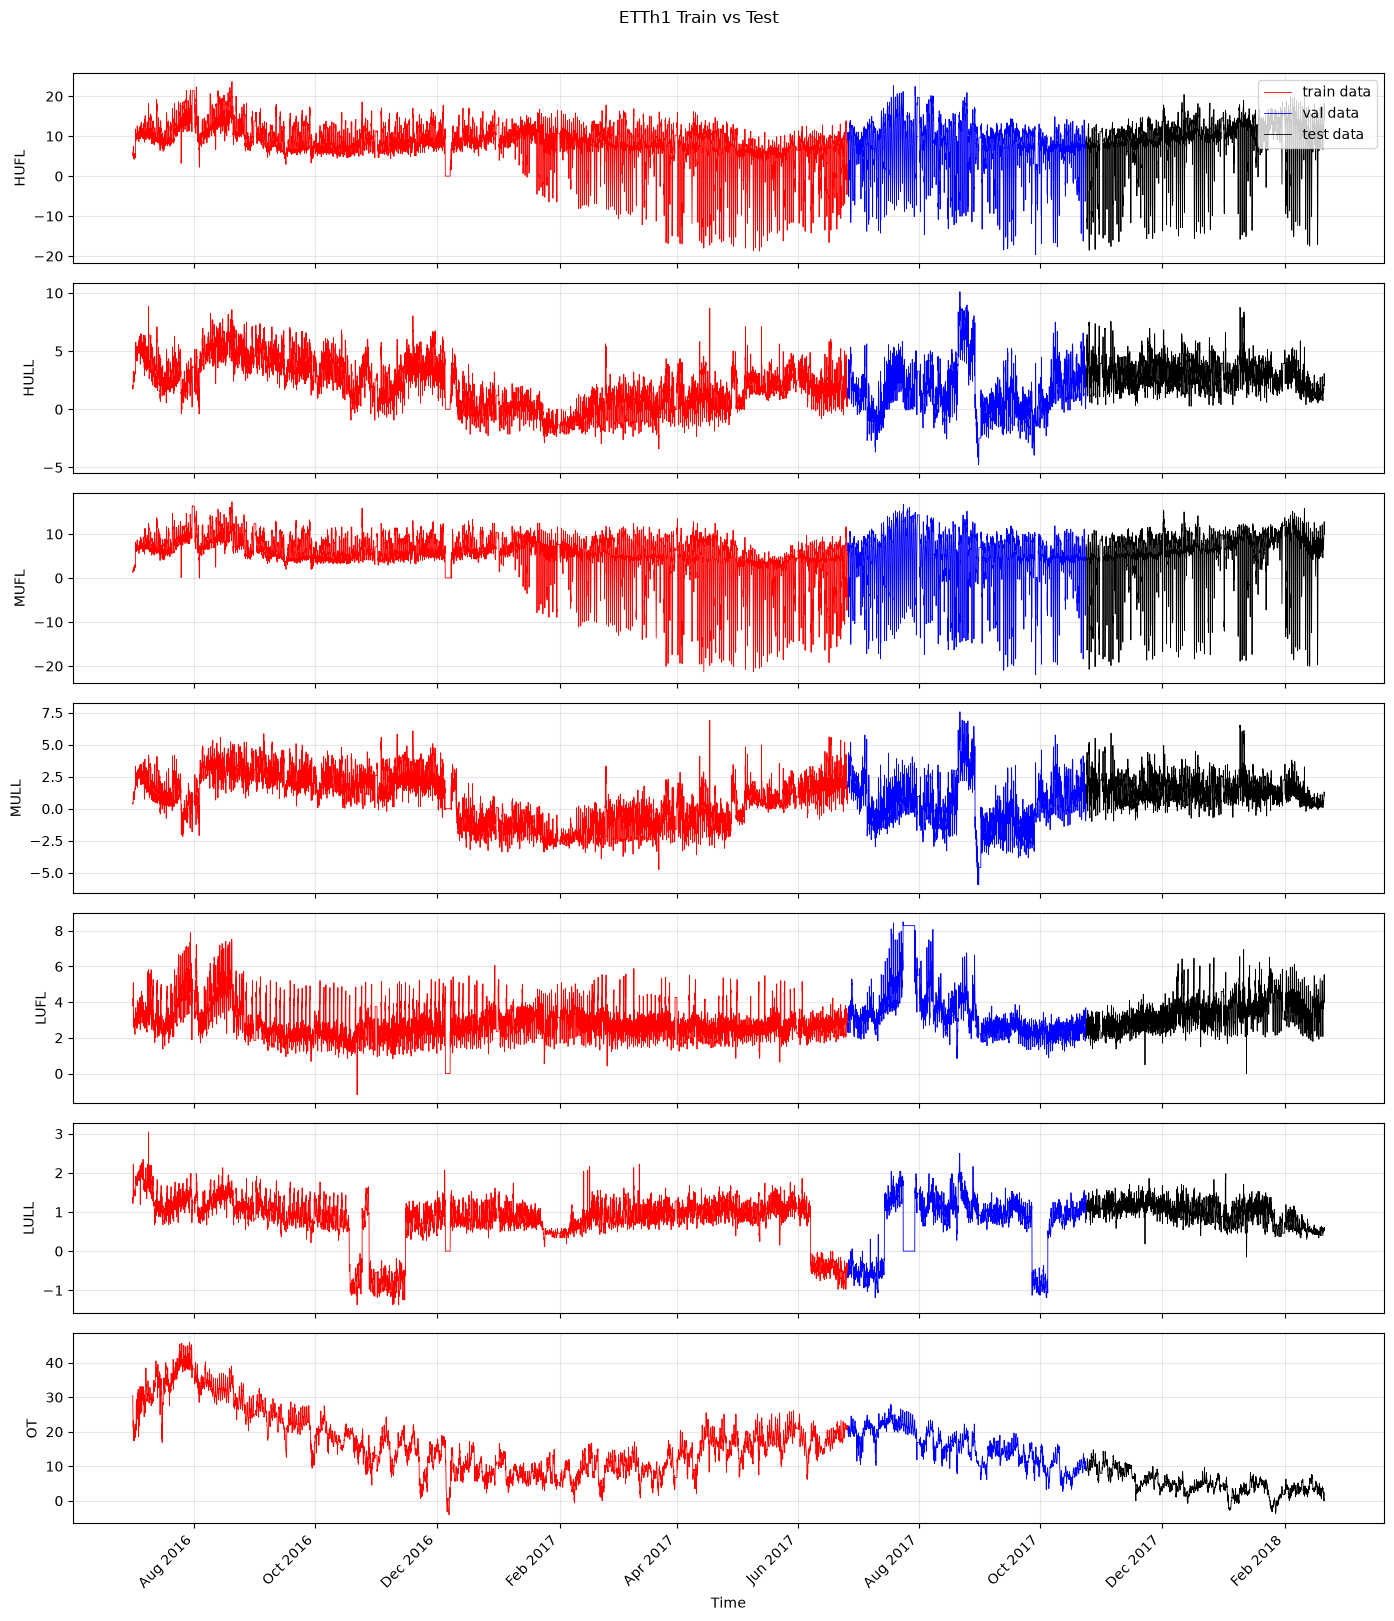

In [9]:
df_etth1 = data_ETTh1

HOURS_PER_MONTH = 30 * 24  # 720h

train_end = 12 * HOURS_PER_MONTH               
val_end   = train_end + 4 * HOURS_PER_MONTH    
test_end  = val_end + 4 * HOURS_PER_MONTH      

train_df = df_etth1.iloc[:train_end]
val_df   = df_etth1.iloc[train_end:val_end]
test_df  = df_etth1.iloc[val_end:test_end]

print(f"Train: {train_df.shape} | {train_df.index.min()} → {train_df.index.max()}")
print(f"Val:   {val_df.shape} | {val_df.index.min()} → {val_df.index.max()}")
print(f"Test:  {test_df.shape} | {test_df.index.min()} → {test_df.index.max()}")

# Plot train vs test for each of the 7 signals
train_dates = dates.iloc[:train_end]
val_dates = dates.iloc[train_end:val_end]
test_dates = dates.iloc[val_end:test_end]

fig, axes = plt.subplots(7, 1, figsize=(14, 16), sharex=True)
for ax, col in zip(axes, df_etth1.columns):
    ax.plot(train_dates, train_df[col], label="train data", color="red", linewidth=0.6)
    ax.plot(val_dates, val_df[col], label="val data", color="blue", linewidth=0.6)
    ax.plot(test_dates, test_df[col], label="test data", color="black", linewidth=0.6)
    ax.set_ylabel(col)
    ax.grid(alpha=0.3)

axes[0].legend(loc="upper right")
axes[-1].set_xlabel("Time")
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha("right")

fig.suptitle("ETTh1 Train vs Test", y=1.01)
plt.tight_layout()
plt.show()





In [10]:
samples = 8640- 96 - 16
print("samples: ", samples)

samples:  8528


In [11]:
## Initialize Dataloader

train_loader = DataLoader(
        train_df,
        batch_size=64,
        shuffle=True,
    )

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

NameError: name 'DataLoader' is not defined